In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import itertools

# Carregar séries
df_series = pd.read_parquet('/home/valentim/divea/data/processed/series_semanais.parquet')

print(f"Shape: {df_series.shape}")
print(df_series.head())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDispositivo: {device}")

Shape: (382, 4)
            casos  influenza  covid  vsr
DT_NOTIFIC                              
2018-12-31     13        1.0    0.0  1.0
2019-01-07     39        1.0    0.0  1.0
2019-01-14     51        2.0    0.0  5.0
2019-01-21     29        1.0    0.0  4.0
2019-01-28     45        1.0    0.0  0.0

Dispositivo: cuda


In [2]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=4, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

def preparar_dados(serie, janela, horizonte=4, split=0.8):
    scaler = MinMaxScaler()
    serie_norm = scaler.fit_transform(serie.reshape(-1, 1))
    X, y = [], []
    for i in range(len(serie_norm) - janela - horizonte):
        X.append(serie_norm[i:i+janela])
        y.append(serie_norm[i+janela:i+janela+horizonte].flatten())
    X, y = np.array(X), np.array(y)
    split_idx = int(len(X) * split)
    return (X[:split_idx], X[split_idx:],
            y[:split_idx], y[split_idx:], scaler)

def treinar_avaliar(serie, janela, hidden_size, num_layers, dropout, epochs=200):
    X_train, X_test, y_train, y_test, scaler = preparar_dados(serie, janela)

    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    X_test_t  = torch.FloatTensor(X_test).to(device)
    y_test_t  = torch.FloatTensor(y_test).to(device)

    model = LSTMModel(hidden_size=hidden_size, num_layers=num_layers, 
                      output_size=4, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = scaler.inverse_transform(model(X_test_t).cpu().numpy())
        real = scaler.inverse_transform(y_test_t.cpu().numpy())

    mae_s1 = mean_absolute_error(real[:, 0], pred[:, 0])
    mae_s4 = mean_absolute_error(real[:, 3], pred[:, 3])
    return mae_s1, mae_s4, model, scaler

print("Funções definidas.")

Funções definidas.


In [3]:
# Grid de hiperparâmetros
janelas = [8, 12, 16, 24]
hidden_sizes = [32, 64, 128]
num_layers_list = [1, 2]
dropouts = [0.1, 0.2]

serie_total = df_series['casos'].values

resultados = []

total = len(janelas) * len(hidden_sizes) * len(num_layers_list) * len(dropouts)
contador = 0

for janela, hidden, layers, dropout in itertools.product(janelas, hidden_sizes, num_layers_list, dropouts):
    contador += 1
    mae1, mae4, _, _ = treinar_avaliar(serie_total, janela, hidden, layers, dropout)
    resultados.append({
        'janela': janela,
        'hidden': hidden,
        'layers': layers,
        'dropout': dropout,
        'mae_s1': round(mae1, 2),
        'mae_s4': round(mae4, 2)
    })
    print(f"[{contador}/{total}] janela={janela} hidden={hidden} layers={layers} dropout={dropout} | MAE+1={mae1:.1f} MAE+4={mae4:.1f}")

df_resultados = pd.DataFrame(resultados)
print("\nConcluído.")

[1/48] janela=8 hidden=32 layers=1 dropout=0.1 | MAE+1=155.5 MAE+4=219.7
[2/48] janela=8 hidden=32 layers=1 dropout=0.2 | MAE+1=146.1 MAE+4=228.8
[3/48] janela=8 hidden=32 layers=2 dropout=0.1 | MAE+1=154.7 MAE+4=227.4
[4/48] janela=8 hidden=32 layers=2 dropout=0.2 | MAE+1=145.9 MAE+4=237.0
[5/48] janela=8 hidden=64 layers=1 dropout=0.1 | MAE+1=117.6 MAE+4=217.9
[6/48] janela=8 hidden=64 layers=1 dropout=0.2 | MAE+1=121.2 MAE+4=213.4
[7/48] janela=8 hidden=64 layers=2 dropout=0.1 | MAE+1=122.7 MAE+4=210.0
[8/48] janela=8 hidden=64 layers=2 dropout=0.2 | MAE+1=127.1 MAE+4=225.8
[9/48] janela=8 hidden=128 layers=1 dropout=0.1 | MAE+1=116.5 MAE+4=219.1
[10/48] janela=8 hidden=128 layers=1 dropout=0.2 | MAE+1=106.5 MAE+4=213.3
[11/48] janela=8 hidden=128 layers=2 dropout=0.1 | MAE+1=96.4 MAE+4=197.3
[12/48] janela=8 hidden=128 layers=2 dropout=0.2 | MAE+1=136.8 MAE+4=230.8
[13/48] janela=12 hidden=32 layers=1 dropout=0.1 | MAE+1=135.3 MAE+4=220.8
[14/48] janela=12 hidden=32 layers=1 dropou

In [4]:
# Top 5 por MAE semana +1
print("=== Top 5 por MAE Semana +1 ===")
print(df_resultados.nsmallest(5, 'mae_s1').to_string(index=False))

# Top 5 por MAE semana +4
print("\n=== Top 5 por MAE Semana +4 ===")
print(df_resultados.nsmallest(5, 'mae_s4').to_string(index=False))

# Melhor combinação geral (menor soma dos dois)
df_resultados['mae_total'] = df_resultados['mae_s1'] + df_resultados['mae_s4']
print("\n=== Top 5 por MAE Total (S1+S4) ===")
print(df_resultados.nsmallest(5, 'mae_total').to_string(index=False))

=== Top 5 por MAE Semana +1 ===
 janela  hidden  layers  dropout  mae_s1  mae_s4
     12     128       2      0.1   76.67  185.55
     16     128       2      0.1   84.18  166.17
     16     128       2      0.2   94.49  187.29
      8     128       2      0.1   96.40  197.26
      8     128       1      0.2  106.50  213.35

=== Top 5 por MAE Semana +4 ===
 janela  hidden  layers  dropout  mae_s1  mae_s4
     16     128       2      0.1   84.18  166.17
     24     128       2      0.2  130.38  174.50
     12     128       2      0.1   76.67  185.55
     16     128       2      0.2   94.49  187.29
     24     128       1      0.1  136.43  194.08

=== Top 5 por MAE Total (S1+S4) ===
 janela  hidden  layers  dropout  mae_s1  mae_s4  mae_total
     16     128       2      0.1   84.18  166.17     250.35
     12     128       2      0.1   76.67  185.55     262.22
     16     128       2      0.2   94.49  187.29     281.78
      8     128       2      0.1   96.40  197.26     293.66
     24   

In [5]:
# Treinar modelo otimizado SRAG Total
mae1, mae4, model_opt, scaler_opt = treinar_avaliar(
    serie_total, 
    janela=16, 
    hidden_size=128, 
    num_layers=2, 
    dropout=0.1,
    epochs=300  # mais épocas para o modelo final
)

print(f"MAE +1: {mae1:.1f}")
print(f"MAE +4: {mae4:.1f}")

# Salvar
import sklearn.preprocessing
torch.save({
    'model_state': model_opt.state_dict(),
    'scaler': scaler_opt,
    'janela': 16,
    'horizonte': 4,
    'config': {'hidden': 128, 'layers': 2, 'dropout': 0.1}
}, '/home/valentim/divea/models/lstm_srag_total_otimizado.pt')

print("Modelo otimizado salvo.")

MAE +1: 89.9
MAE +4: 175.8
Modelo otimizado salvo.


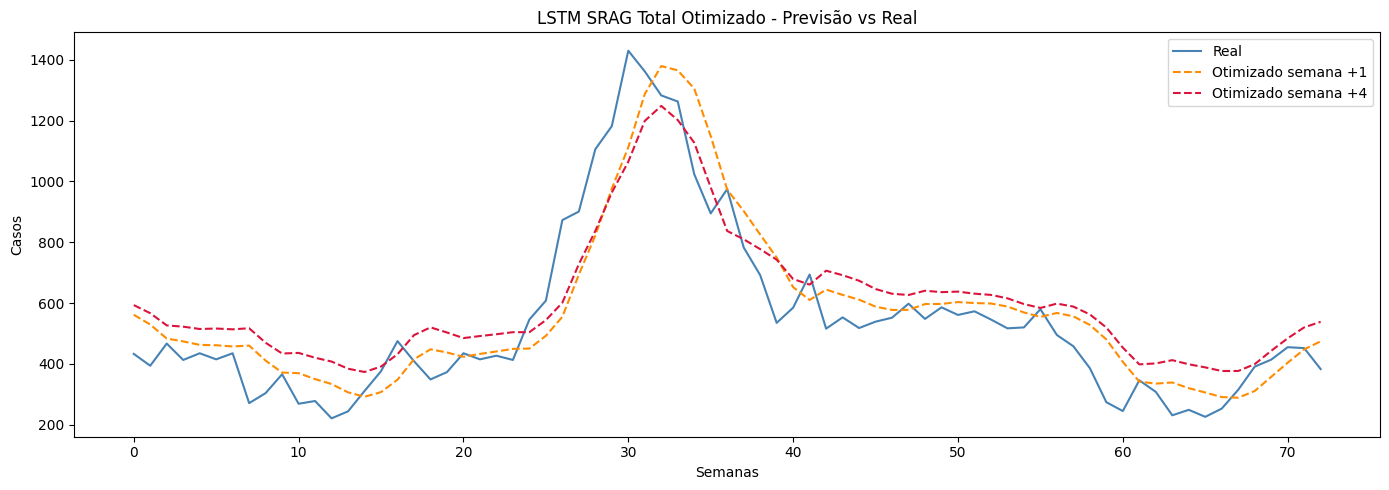

In [6]:
# Comparação baseline vs otimizado
X_train, X_test, y_train, y_test, scaler_opt = preparar_dados(serie_total, janela=16)

X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

model_opt.eval()
with torch.no_grad():
    pred_opt = scaler_opt.inverse_transform(model_opt(X_test_t).cpu().numpy())
    real = scaler_opt.inverse_transform(y_test_t.cpu().numpy())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(real[:, 0], label='Real', color='steelblue', linewidth=1.5)
ax.plot(pred_opt[:, 0], label='Otimizado semana +1', color='darkorange', linewidth=1.5, linestyle='--')
ax.plot(pred_opt[:, 3], label='Otimizado semana +4', color='crimson', linewidth=1.5, linestyle='--')
ax.set_title('LSTM SRAG Total Otimizado - Previsão vs Real')
ax.set_xlabel('Semanas')
ax.set_ylabel('Casos')
ax.legend()
plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/lstm_srag_otimizado.png', dpi=150)
plt.show()

In [7]:
# Grid search Influenza (excluindo período pandêmico)
df_flu = df_series['influenza'].copy()
df_flu = df_flu[(df_flu.index < '2020-01-01') | (df_flu.index >= '2022-01-01')]
serie_flu = df_flu.values

resultados_flu = []
contador = 0

for janela, hidden, layers, dropout in itertools.product(janelas, hidden_sizes, num_layers_list, dropouts):
    contador += 1
    mae1, mae4, _, _ = treinar_avaliar(serie_flu, janela, hidden, layers, dropout)
    resultados_flu.append({
        'janela': janela, 'hidden': hidden, 'layers': layers,
        'dropout': dropout, 'mae_s1': round(mae1, 2), 'mae_s4': round(mae4, 2)
    })
    print(f"[{contador}/48] janela={janela} hidden={hidden} layers={layers} dropout={dropout} | MAE+1={mae1:.1f} MAE+4={mae4:.1f}")

df_flu_resultados = pd.DataFrame(resultados_flu)
df_flu_resultados['mae_total'] = df_flu_resultados['mae_s1'] + df_flu_resultados['mae_s4']
print("\n=== Top 5 Influenza por MAE Total ===")
print(df_flu_resultados.nsmallest(5, 'mae_total').to_string(index=False))

[1/48] janela=8 hidden=32 layers=1 dropout=0.1 | MAE+1=30.2 MAE+4=45.9
[2/48] janela=8 hidden=32 layers=1 dropout=0.2 | MAE+1=29.8 MAE+4=46.0
[3/48] janela=8 hidden=32 layers=2 dropout=0.1 | MAE+1=25.6 MAE+4=43.0
[4/48] janela=8 hidden=32 layers=2 dropout=0.2 | MAE+1=29.8 MAE+4=44.4
[5/48] janela=8 hidden=64 layers=1 dropout=0.1 | MAE+1=21.6 MAE+4=41.1
[6/48] janela=8 hidden=64 layers=1 dropout=0.2 | MAE+1=21.4 MAE+4=39.5
[7/48] janela=8 hidden=64 layers=2 dropout=0.1 | MAE+1=22.4 MAE+4=40.8
[8/48] janela=8 hidden=64 layers=2 dropout=0.2 | MAE+1=26.2 MAE+4=46.6
[9/48] janela=8 hidden=128 layers=1 dropout=0.1 | MAE+1=18.4 MAE+4=41.6
[10/48] janela=8 hidden=128 layers=1 dropout=0.2 | MAE+1=17.0 MAE+4=40.6
[11/48] janela=8 hidden=128 layers=2 dropout=0.1 | MAE+1=25.0 MAE+4=45.1
[12/48] janela=8 hidden=128 layers=2 dropout=0.2 | MAE+1=24.7 MAE+4=46.3
[13/48] janela=12 hidden=32 layers=1 dropout=0.1 | MAE+1=25.1 MAE+4=43.4
[14/48] janela=12 hidden=32 layers=1 dropout=0.2 | MAE+1=31.1 MAE+4=

In [8]:
# Grid search VSR
serie_vsr = df_series['vsr'].values

resultados_vsr = []
contador = 0

for janela, hidden, layers, dropout in itertools.product(janelas, hidden_sizes, num_layers_list, dropouts):
    contador += 1
    mae1, mae4, _, _ = treinar_avaliar(serie_vsr, janela, hidden, layers, dropout)
    resultados_vsr.append({
        'janela': janela, 'hidden': hidden, 'layers': layers,
        'dropout': dropout, 'mae_s1': round(mae1, 2), 'mae_s4': round(mae4, 2)
    })
    print(f"[{contador}/48] janela={janela} hidden={hidden} layers={layers} dropout={dropout} | MAE+1={mae1:.1f} MAE+4={mae4:.1f}")

df_vsr_resultados = pd.DataFrame(resultados_vsr)
df_vsr_resultados['mae_total'] = df_vsr_resultados['mae_s1'] + df_vsr_resultados['mae_s4']
print("\n=== Top 5 VSR por MAE Total ===")
print(df_vsr_resultados.nsmallest(5, 'mae_total').to_string(index=False))

[1/48] janela=8 hidden=32 layers=1 dropout=0.1 | MAE+1=15.5 MAE+4=34.6
[2/48] janela=8 hidden=32 layers=1 dropout=0.2 | MAE+1=23.7 MAE+4=38.0
[3/48] janela=8 hidden=32 layers=2 dropout=0.1 | MAE+1=20.0 MAE+4=35.2
[4/48] janela=8 hidden=32 layers=2 dropout=0.2 | MAE+1=20.4 MAE+4=34.8
[5/48] janela=8 hidden=64 layers=1 dropout=0.1 | MAE+1=20.3 MAE+4=31.5
[6/48] janela=8 hidden=64 layers=1 dropout=0.2 | MAE+1=18.6 MAE+4=33.3
[7/48] janela=8 hidden=64 layers=2 dropout=0.1 | MAE+1=20.5 MAE+4=32.9
[8/48] janela=8 hidden=64 layers=2 dropout=0.2 | MAE+1=23.0 MAE+4=33.3
[9/48] janela=8 hidden=128 layers=1 dropout=0.1 | MAE+1=19.2 MAE+4=32.0
[10/48] janela=8 hidden=128 layers=1 dropout=0.2 | MAE+1=19.6 MAE+4=31.0
[11/48] janela=8 hidden=128 layers=2 dropout=0.1 | MAE+1=17.7 MAE+4=30.3
[12/48] janela=8 hidden=128 layers=2 dropout=0.2 | MAE+1=17.3 MAE+4=30.8
[13/48] janela=12 hidden=32 layers=1 dropout=0.1 | MAE+1=18.8 MAE+4=37.4
[14/48] janela=12 hidden=32 layers=1 dropout=0.2 | MAE+1=21.0 MAE+4=

In [9]:
# Treinar e salvar modelo otimizado Influenza
mae1, mae4, model_flu_opt, scaler_flu_opt = treinar_avaliar(
    serie_flu, janela=8, hidden_size=128, num_layers=1, dropout=0.2, epochs=300
)
print(f"Influenza otimizado — MAE +1: {mae1:.1f} | MAE +4: {mae4:.1f}")

torch.save({
    'model_state': model_flu_opt.state_dict(),
    'scaler': scaler_flu_opt,
    'janela': 8,
    'horizonte': 4,
    'config': {'hidden': 128, 'layers': 1, 'dropout': 0.2}
}, '/home/valentim/divea/models/lstm_influenza_otimizado.pt')

# Treinar e salvar modelo otimizado VSR
mae1, mae4, model_vsr_opt, scaler_vsr_opt = treinar_avaliar(
    serie_vsr, janela=8, hidden_size=128, num_layers=2, dropout=0.1, epochs=300
)
print(f"VSR otimizado — MAE +1: {mae1:.1f} | MAE +4: {mae4:.1f}")

torch.save({
    'model_state': model_vsr_opt.state_dict(),
    'scaler': scaler_vsr_opt,
    'janela': 8,
    'horizonte': 4,
    'config': {'hidden': 128, 'layers': 2, 'dropout': 0.1}
}, '/home/valentim/divea/models/lstm_vsr_otimizado.pt')

print("\nModelos otimizados salvos.")

Influenza otimizado — MAE +1: 21.7 | MAE +4: 44.9
VSR otimizado — MAE +1: 19.2 | MAE +4: 31.2

Modelos otimizados salvos.


In [10]:
# Tabela comparativa baseline vs otimizado
comparativo = pd.DataFrame({
    'Modelo': ['SRAG Total', 'SRAG Total', 'Influenza', 'Influenza', 'VSR', 'VSR'],
    'Versão': ['Baseline', 'Otimizado', 'Baseline', 'Otimizado', 'Baseline', 'Otimizado'],
    'MAE +1': [106.7, 89.9, 22.0, 21.7, 17.9, 19.2],
    'MAE +4': [206.2, 175.8, 34.5, 44.9, 32.8, 31.2]
})

print(comparativo.to_string(index=False))

    Modelo    Versão  MAE +1  MAE +4
SRAG Total  Baseline   106.7   206.2
SRAG Total Otimizado    89.9   175.8
 Influenza  Baseline    22.0    34.5
 Influenza Otimizado    21.7    44.9
       VSR  Baseline    17.9    32.8
       VSR Otimizado    19.2    31.2
